### create baseline model: random forest regressor

In [40]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [29]:
PROCESSED_PATH = Path("../data/processed/rolling_sample.parquet")

df_rolling = pd.read_parquet(PROCESSED_PATH)
print(df_rolling.shape)
df_rolling.head()

(2136, 28)


,datetime,dt,hour,demand,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,...,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24
0,2024-03-29 00:00:00,2024-03-29,0,0.6,0.0,0.8,0.5,1.1,3.18,2.70,...,5.4,7.2,4.2,1.7,0.7,0.2,0.2,0.0,0.0,0.3
1,2024-03-29 01:00:00,2024-03-29,1,0.3,0.6,0.0,0.8,0.5,1.10,3.18,...,7.2,5.4,7.2,4.2,1.7,0.7,0.2,0.2,0.0,0.0
2,2024-03-29 02:00:00,2024-03-29,2,0.0,0.3,0.6,0.0,0.8,0.50,1.10,...,4.4,7.2,5.4,7.2,4.2,1.7,0.7,0.2,0.2,0.0
3,2024-03-29 03:00:00,2024-03-29,3,0.4,0.0,0.3,0.6,0.0,0.80,0.50,...,3.7,4.4,7.2,5.4,7.2,4.2,1.7,0.7,0.2,0.2
4,2024-03-29 04:00:00,2024-03-29,4,0.1,0.4,0.0,0.3,0.6,0.00,0.80,...,2.4,3.7,4.4,7.2,5.4,7.2,4.2,1.7,0.7,0.2


In [30]:
df_rolling.columns

Index(['datetime', 'dt', 'hour', 'demand', 'lag_1', 'lag_2', 'lag_3', 'lag_4',
       'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11',
       'lag_12', 'lag_13', 'lag_14', 'lag_15', 'lag_16', 'lag_17', 'lag_18',
       'lag_19', 'lag_20', 'lag_21', 'lag_22', 'lag_23', 'lag_24'],
      dtype='str')

In [31]:
feature_cols = [
    'lag_1', 'lag_2', 'lag_3', 'lag_4',
       'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11',
       'lag_12', 'lag_13', 'lag_14', 'lag_15', 'lag_16', 'lag_17', 'lag_18',
       'lag_19', 'lag_20', 'lag_21', 'lag_22', 'lag_23', 'lag_24', 'hour'
]

X = df_rolling[feature_cols]
y = df_rolling["demand"]

In [32]:
train_size = int(len(df_rolling) * 0.8)

train_df = df_rolling.iloc[:train_size]
test_df = df_rolling.iloc[train_size:]

X_train = train_df[feature_cols]
y_train = train_df["demand"]

X_test = test_df[feature_cols]
y_test = test_df["demand"]

In [33]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [34]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 1.0381
RMSE: 1.5211


In [55]:
predictions = test_df[["datetime", "demand"]].copy()
predictions["prediction"] = y_pred
predictions["model"] = "random_forest"
predictions

,datetime,demand,prediction,model
1708,2024-06-08 04:00:00,0.60,0.2280,random_forest
1709,2024-06-08 05:00:00,1.40,0.8230,random_forest
1710,2024-06-08 06:00:00,4.20,2.8030,random_forest
1711,2024-06-08 07:00:00,8.80,4.5790,random_forest
1712,2024-06-08 08:00:00,15.40,13.5070,random_forest
...,...,...,...,...
2131,2024-06-25 19:00:00,4.92,4.3977,random_forest
2132,2024-06-25 20:00:00,4.80,3.1796,random_forest
2133,2024-06-25 21:00:00,2.10,2.4284,random_forest
2134,2024-06-25 22:00:00,2.10,1.9190,random_forest


In [57]:
PREDICTION_PATH = Path("../outputs/predictions/random_forest_predictions.parquet")
PREDICTION_PATH.parent.mkdir(parents=True, exist_ok=True)

predictions.to_parquet(PREDICTION_PATH, index=False)

In [59]:
metrics = pd.DataFrame([
    {
        "model": "random_forest",
        "mae": mae,
        "rmse": rmse,
    }
])

METRICS_PATH = Path("../outputs/evaluation/random_forest_metrics.csv")
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

metrics.to_csv(METRICS_PATH, index=False)

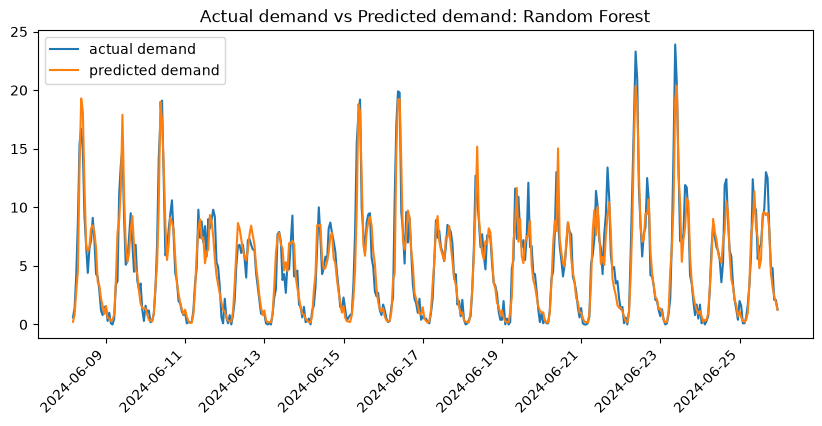

<Figure size 640x480 with 0 Axes>

In [54]:
VIZ_PATH = Path("../outputs/figures")

plt.figure(figsize=(10, 4))
plt.plot(predictions['datetime'], predictions['demand'], label = "actual demand")
plt.plot(predictions['datetime'], predictions['prediction'], label = "predicted demand")
plt.xticks(rotation=45, ha='right') 
plt.legend()
plt.title("Actual demand vs Predicted demand: Random Forest")
plt.show()

plt.savefig(f'{VIZ_PATH}/act_vs_pred_rf.png')